# **Convolution Neural Network (CNN)**

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

**CIFAR Dataset:  **
CIFAR-10 is a standard image classification dataset used to train and test convolutional neural networks (CNNs).

It contains:

60,000 color images

Image size: 32 × 32 pixels

10 different **classes**

50,000 training images

10,000 test images

Each class has 6,000 images, so the dataset is nicely balanced.

CIFAR-10 classes

Each image belongs to one of these categories:

Airplane

Automobile

Bird

Cat

Deer

Dog

Frog

Horse

Ship

Truck

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
X_train.shape

(50000, 32, 32, 3)

[6]


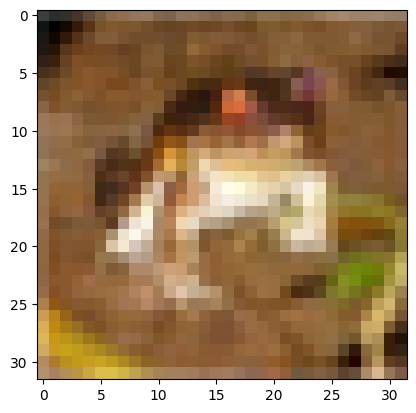

In [ ]:
print(y_train[0])
plt.imshow(X_train[0])

In [ ]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

frog


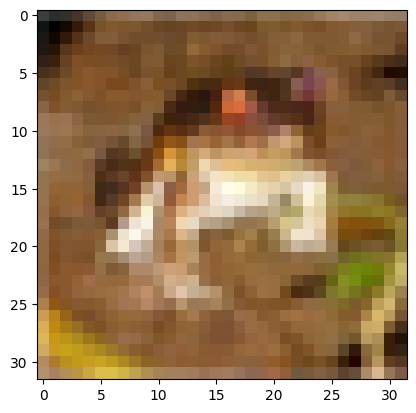

In [ ]:
print(class_names[y_train[0][0]])
plt.imshow(X_train[0])

# **Building CNN**

In [ ]:
model = models.Sequential()

# -------- Conv Layer 1 --------
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='valid',
    strides=(1,1),
    activation='relu',
    input_shape=(32, 32, 3)
))
model.add(layers.MaxPooling2D((2, 2)))

# -------- Conv Layer 2 --------
model.add(layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='valid',
    strides=(1,1),
    activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# -------- Conv Layer 3 --------
model.add(layers.Conv2D(
    filters=128,
    kernel_size=(3, 3),
    padding='valid',
    strides=(1,1),
    activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten
model.add(layers.Flatten())

# Fully connected layer
model.add(layers.Dense(64, activation='relu'))

# Output layer (10 classes)
model.add(layers.Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,730 (495.04 KB)

 Trainable params: 126,730 (495.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3332 - loss: 1.8035 - val_accuracy: 0.5294 - val_loss: 1.3143
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5499 - loss: 1.2649 - val_accuracy: 0.5813 - val_loss: 1.1955
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6229 - loss: 1.0766 - val_accuracy: 0.6260 - val_loss: 1.0772
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6593 - loss: 0.9719 - val_accuracy: 0.6714 - val_loss: 0.9465
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6988 - loss: 0.8648 - val_accuracy: 0.6805 - val_loss: 0.9254
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7250 - loss: 0.7990 - val_accuracy: 0.6654 - val_loss: 0.9529
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7422 - loss: 0.7424 - val_accuracy: 0.6945 - val_loss: 0.8933
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7602 - loss: 0.6923 - val_accuracy: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7117 - loss: 1.2760
Test Accuracy: 0.7067999839782715


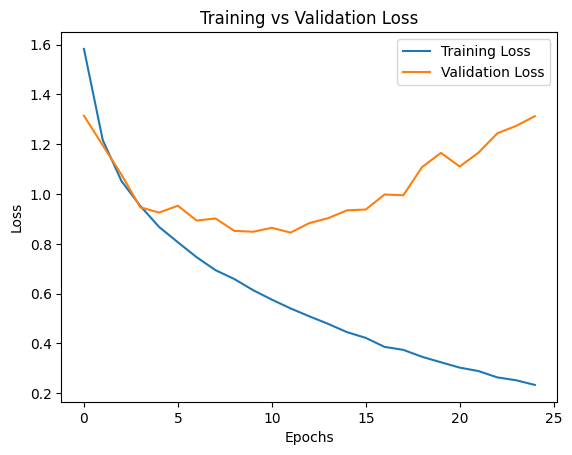

In [ ]:
# loss plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

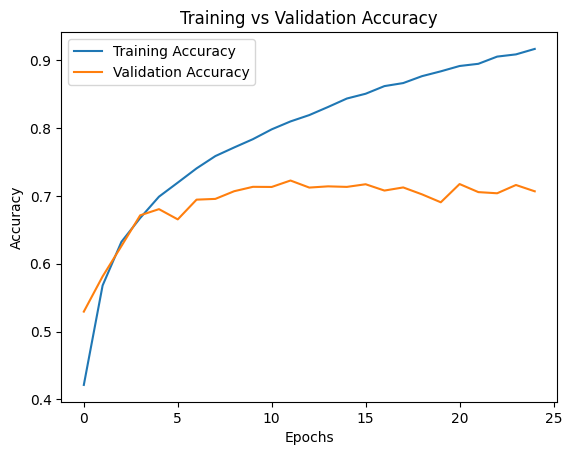

In [ ]:
# accuracy plot

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

In [ ]:
[0.2 0.3]

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


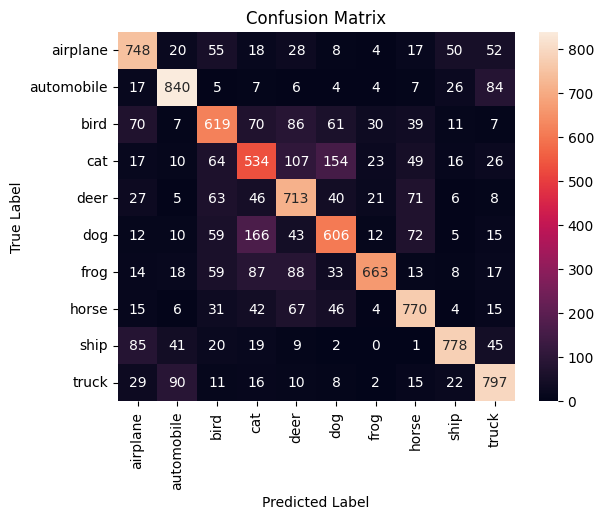

In [ ]:
# confusion matrix plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
#plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## **This model overfits**

## **Avoid Overfitting**

In [ ]:
model = models.Sequential()

# -------- Conv Layer 1 --------
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='valid',
    strides=(1,1),
    activation='relu',
    input_shape=(32, 32, 3)
))
model.add(layers.MaxPooling2D((2, 2)))
# dropout layer
model.add(layers.Dropout(0.25))

# -------- Conv Layer 2 --------
model.add(layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='valid',
    strides=(1,1),
    activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
# dropout layer
model.add(layers.Dropout(0.25))

# -------- Conv Layer 3 --------
model.add(layers.Conv2D(
    filters=128,
    kernel_size=(3, 3),
    padding='valid',
    strides=(1,1),
    activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
# dropout layer
model.add(layers.Dropout(0.25))

# Flatten
model.add(layers.Flatten())

# Fully connected layer
model.add(layers.Dense(64, activation='relu'))
# dropout layer
model.add(layers.Dropout(0.5))

# Output layer (10 classes)
model.add(layers.Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,730 (495.04 KB)

 Trainable params: 126,730 (495.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    #validation_split=0.1,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.2234 - loss: 2.0292 - val_accuracy: 0.4628 - val_loss: 1.4872
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4322 - loss: 1.5533 - val_accuracy: 0.5279 - val_loss: 1.3123
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4995 - loss: 1.3961 - val_accuracy: 0.5691 - val_loss: 1.2037
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5322 - loss: 1.3167 - val_accuracy: 0.6148 - val_loss: 1.0877
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5637 - loss: 1.2333 - val_accuracy: 0.6129 - val_loss: 1.1000
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5806 - loss: 1.1953 - val_accuracy: 0.6468 - val_loss: 1.0191
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5975 - loss: 1.1556 - val_accuracy: 0.6675 - val_loss: 0.9529
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6135 - loss: 1.1032 - val_accuracy: 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7244 - loss: 0.8005
Test Accuracy: 0.7279000282287598


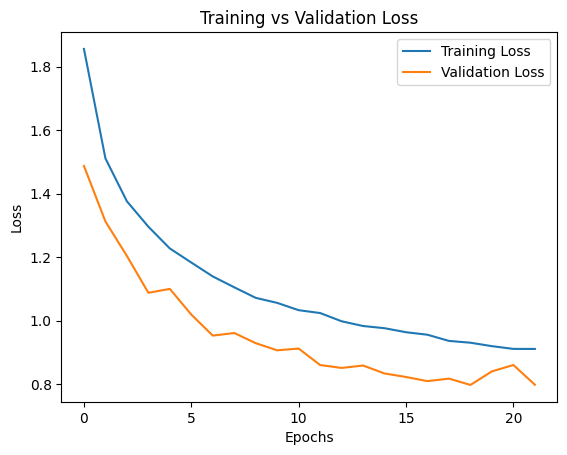

In [ ]:
# loss plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

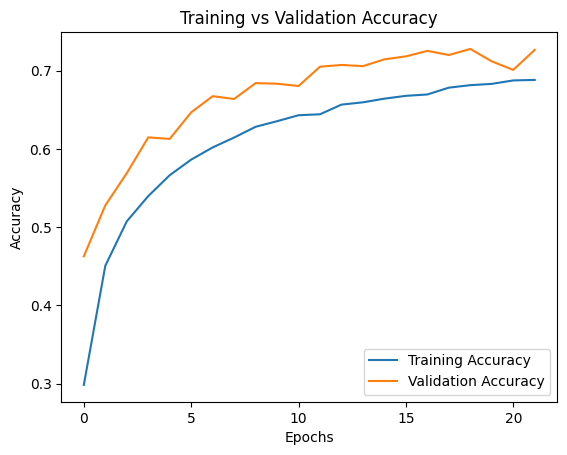

In [ ]:
# accuracy plot

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


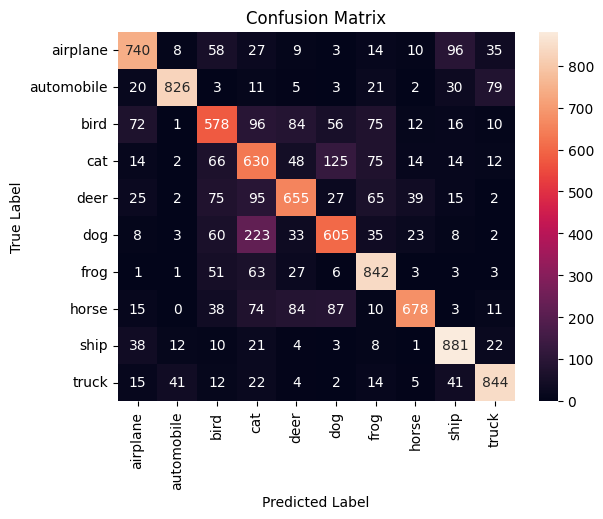

In [ ]:
# confusion matrix plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
#plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## **Save and load model**

In [ ]:
# save model
model.save("cifar10_cnn_model.h5")

# load model
from tensorflow.keras.models import load_model

loaded_model = load_model("cifar10_cnn_model.h5")

## **inferencing model for prediction**

In [ ]:
X_test[0].shape

(32, 32, 3)

In [ ]:
(1, 32, 32,3)

In [ ]:
test_img = np.expand_dims(X_test[0], axis=0)
test_img.shape

(1, 32, 32, 3)

In [ ]:
y_test[0]

array([3], dtype=uint8)

In [ ]:
prediction = model.predict(test_img)
print("Actual class: ", class_names[y_test[0][0]])
print("Predicted class: ", class_names[np.argmax(prediction[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
Actual class:  cat
Predicted class:  cat


In [ ]:
from PIL import Image

In [ ]:
def load_and_preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((32, 32))        # input size size
    img = np.array(img) / 255.0       # Normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img


In [ ]:
image_path = "/content/download.jpg"  # your image file
img = load_and_preprocess_image(image_path)

In [ ]:
img.shape

(1, 32, 32, 3)

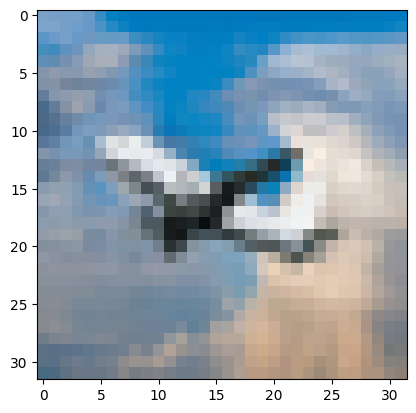

In [ ]:
plt.imshow(img[0])

In [ ]:
prediction = model.predict(img)
print(prediction)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[[9.9530548e-01 2.1858804e-07 4.3911543e-03 1.6375207e-05 1.5304497e-04
  1.3234520e-06 1.0757228e-06 1.6395122e-06 1.2293873e-04 6.7319875e-06]]
Predicted class: airplane


In [ ]:
image_path = "/content/download (1).jfif"  # your image file
img = load_and_preprocess_image(image_path)

prediction = loaded_model.predict(img)
print(prediction)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
[[8.11371719e-04 1.20221615e-04 9.93063822e-02 1.82799157e-03
  8.69827997e-03 1.40129312e-04 8.88111293e-01 7.46736032e-06
  7.96006643e-04 1.80827366e-04]]
Predicted class: frog


## **Creating App**

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

In [ ]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
def predict(image):
  # preprocessing image
  image = image.resize((32, 32))        # CIFAR-10 size
  image = np.array(image) / 255.0       # Normalize
  image = np.expand_dims(image, axis=0)  # Add batch dimension

  # Predict
  predictions = model.predict(image)
  predicted_class = class_names[np.argmax(predictions)]
  confidence = np.max(predictions)

  return {predicted_class: float(confidence)}


In [ ]:
# Create Gradio interface
app_ui = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(),
    title="CNN Image Classifier",
    description="Upload an image and the CNN will predict the class."
)

In [ ]:
app_ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://722b525a061351da13.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### [**How to create your own dataset**](https://)

In [ ]:
!unzip /content/asl_dataset.zip -d /content/asl_dataset

Archive:  /content/asl_dataset.zip
   creating: /content/asl_dataset/asl_dataset/
   creating: /content/asl_dataset/asl_dataset/0/
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_bot_seg_1_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_bot_seg_2_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_bot_seg_3_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_bot_seg_4_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_bot_seg_5_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_dif_seg_1_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_dif_seg_2_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_dif_seg_3_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_dif_seg_4_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_dif_seg_5_cropped.jpeg  
  inflating: /content/asl_dataset/asl_dataset/0/hand1_0_lef

dataset/

    train/
        class1/
            img1.jpg
            img2.jpg
        class2/
            img3.jpg
            img4.jpg

    test/
        class1/
        class2/


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ---------- TRAIN DATA (with augmentation) ----------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.1   # 10% of train → validation
)

train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

# ---------- TEST DATA (NO augmentation) ----------
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


In [ ]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)
